In [ ]:
import tensorflow as tf
import numpy as np
import os

# Définissez le dossier de log et l'epoch à vérifier
log_dir = "./logs/fit/20250304-094830"  # adapter
checkpoint_prefix = os.path.join(log_dir, "embeddings_epoch_0.ckpt-1")

# Vérifier si le checkpoint existe
if not os.path.exists(checkpoint_prefix + ".index"):
    raise FileNotFoundError(f"Le checkpoint {checkpoint_prefix} n'existe pas.")

# Charger le checkpoint et lister les variables
reader = tf.train.load_checkpoint(log_dir)
tensor_names = reader.get_variable_to_shape_map().keys()

print("📌 Variables présentes dans le checkpoint :")
for name in tensor_names:
    print(name)

# Charger correctement les embeddings en utilisant le chemin correct
embedding_key = "embeddings/.ATTRIBUTES/VARIABLE_VALUE"
if embedding_key in tensor_names:
    embeddings = reader.get_tensor(embedding_key)
    print("\n✅ Embeddings trouvés et chargés !")
    print("Shape des embeddings :", embeddings.shape)
    print("Moyenne :", embeddings.mean())
    print("Écart-type :", embeddings.std())
else:
    print("\n🚨 Impossible de trouver les embeddings dans le checkpoint.")


📌 Variables présentes dans le checkpoint :
save_counter/.ATTRIBUTES/VARIABLE_VALUE
embeddings/.ATTRIBUTES/VARIABLE_VALUE
_CHECKPOINTABLE_OBJECT_GRAPH

✅ Embeddings trouvés et chargés !
Shape des embeddings : (100, 131072)
Moyenne : 0.17403768
Écart-type : 0.6164793


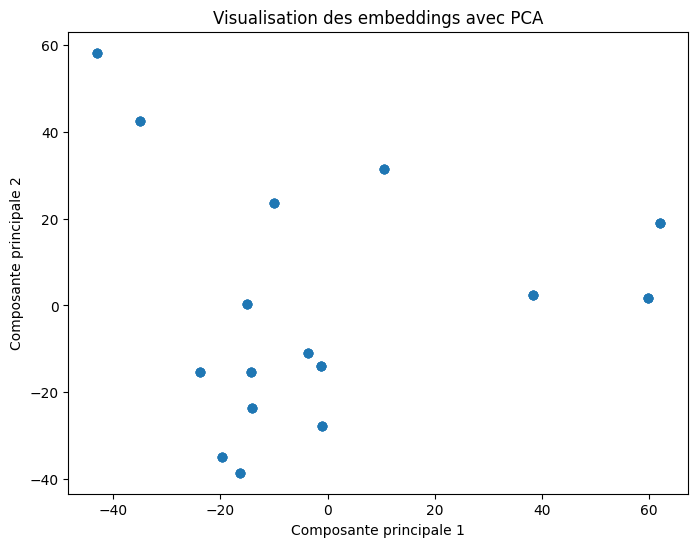

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Charger les embeddings depuis la variable
embeddings_2D = PCA(n_components=2).fit_transform(embeddings)

# Affichage
plt.figure(figsize=(8, 6))
plt.scatter(embeddings_2D[:, 0], embeddings_2D[:, 1], alpha=0.7)
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Visualisation des embeddings avec PCA")
plt.show()
